In [1]:
import os
import numpy as np
import sys
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [3]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
latent_array = joblib.load(os.path.join(root_dir, 'latent_array_plus6_ctrl_y.pkl'))
patch_label_df = pd.read_csv(os.path.join(root_dir, 'patch_label_df.csv'))


In [4]:
patch_label_df

,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,vinculin_intensity,pax_intensity,actin_intensity,dist_cell_edge,front_flag
0,0,ctrl,f0000x0080y0816ps32.tif,0,0,0,0,0,3470.368164,10741.897461,12359.537109,0.0,0.0
1,1,ctrl,f0000x0112y0784ps32.tif,0,0,0,0,0,2753.338867,8699.333984,13098.292969,0.0,0.0
2,2,ctrl,f0000x0144y0784ps32.tif,0,0,0,0,0,4177.766602,12690.236328,16727.391602,8.0,0.0
3,3,ctrl,f0000x0176y0784ps32.tif,0,0,0,0,0,3782.319336,9358.561523,17598.548828,4.0,0.0
4,4,ctrl,f0000x0240y0752ps32.tif,0,0,0,0,0,3487.683594,8591.057617,16351.705078,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23651,23651,y,f0040x0912y0624ps32.tif,1,0,0,0,0,4753.446289,6024.557617,11125.858398,24.0,255.0
23652,23652,y,f0040x0912y0656ps32.tif,1,0,0,0,0,8459.265625,8512.615234,12954.887695,25.0,255.0
23653,23653,y,f0040x0912y0688ps32.tif,1,0,0,0,0,7675.988281,8302.816406,8516.779297,28.0,255.0
23654,23654,y,f0040x0912y0720ps32.tif,1,0,0,0,0,5432.383789,5537.922852,10739.161133,16.0,255.0


In [4]:
latent_array_np_lat8 = latent_array[:,:8]
latents_lat8_2d = UMAP_train(latent_array_np_lat8, root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8only_UMAP2_20251222')

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [5]:
patch_label_df['UMAP_d0'] = latents_lat8_2d[:,0]
patch_label_df['UMAP_d1'] = latents_lat8_2d[:,1]


In [6]:
patch_label_df['lat_d0'] = latent_array_np_lat8[:,0]
patch_label_df['lat_d1'] = latent_array_np_lat8[:,1]
patch_label_df['lat_d2'] = latent_array_np_lat8[:,2]
patch_label_df['lat_d3'] = latent_array_np_lat8[:,3]
patch_label_df['lat_d4'] = latent_array_np_lat8[:,4]
patch_label_df['lat_d5'] = latent_array_np_lat8[:,5]
patch_label_df['lat_d6'] = latent_array_np_lat8[:,6]
patch_label_df['lat_d7'] = latent_array_np_lat8[:,7]

In [7]:
patch_label_df

,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,vinculin_intensity,pax_intensity,...,dist_cell_edge,front_flag,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
0,0,ctrl,f0000x0080y0816ps32.tif,0,6.533898,2.949632,0,0,3470.368164,10741.897461,...,0.0,0.0,4.793272,20.604002,5.372108,-7.815341,1.760113,32.959721,-21.882824,2.258103
1,1,ctrl,f0000x0112y0784ps32.tif,0,0.613508,-1.430238,0,0,2753.338867,8699.333984,...,0.0,0.0,0.826394,-3.398712,-2.768886,5.473682,-1.714877,1.444764,-5.044192,-2.793007
2,2,ctrl,f0000x0144y0784ps32.tif,0,4.134789,1.867131,0,0,4177.766602,12690.236328,...,8.0,0.0,10.628540,3.866692,-0.625196,2.456605,0.941578,6.303121,-6.728461,-7.896038
3,3,ctrl,f0000x0176y0784ps32.tif,0,6.328398,2.741769,0,0,3782.319336,9358.561523,...,4.0,0.0,13.097126,9.377098,7.463983,-0.638954,3.322603,22.364613,-18.249426,0.339599
4,4,ctrl,f0000x0240y0752ps32.tif,0,5.109221,1.633341,0,0,3487.683594,8591.057617,...,6.0,0.0,15.051421,4.962876,1.968619,4.266151,3.475077,12.175271,-11.814137,-9.985755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23651,23651,y,f0040x0912y0624ps32.tif,1,6.696744,0.453905,0,0,4753.446289,6024.557617,...,24.0,255.0,-4.928203,4.098186,-5.373686,4.427641,-0.110387,9.007499,-16.987860,-2.702754
23652,23652,y,f0040x0912y0656ps32.tif,1,5.160360,1.301750,0,0,8459.265625,8512.615234,...,25.0,255.0,9.884430,6.437505,1.430342,7.115860,2.850735,12.949064,-10.358782,-3.006688
23653,23653,y,f0040x0912y0688ps32.tif,1,3.375209,-0.521952,0,0,7675.988281,8302.816406,...,28.0,255.0,1.726854,-1.704976,-4.656003,1.686419,1.671660,7.410644,-7.135116,-0.333692
23654,23654,y,f0040x0912y0720ps32.tif,1,5.753994,-0.231215,0,0,5432.383789,5537.922852,...,16.0,255.0,0.885759,-2.416347,-6.106094,3.669299,-1.798731,8.590202,-13.161478,-6.561848


In [8]:
patch_label_df["group"] = patch_label_df["ctrl_y_str"].map(
    {"ctrl": "control", "y": "ycomp"}
)


patch_label_df["unique_ID"]  = patch_label_df["group"] +'-'+patch_label_df["crop_img_filename"] 


In [9]:
patch_label_df.to_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))

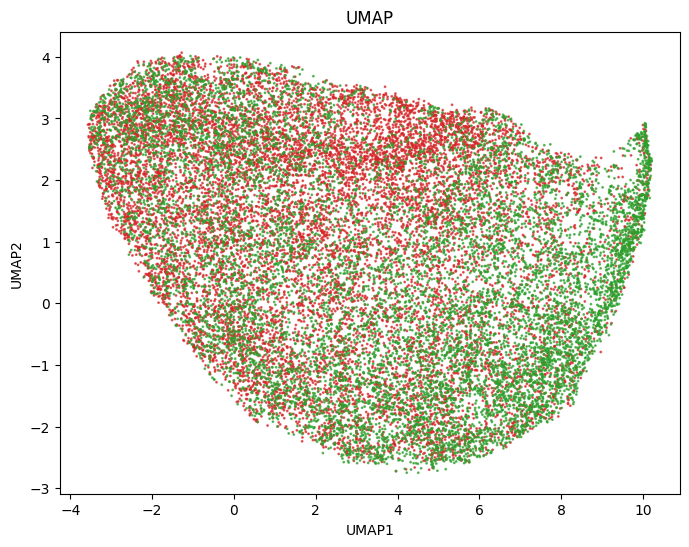

In [10]:
fig = umap_2Dplot(latents_lat8_2d, 0,1,1-patch_label_df['group_labels']+1)

In [11]:
def ctrl_Y_ID_adding(label_df):
    label_df["group"] = (
    label_df["czi_filename"]
    .str.lower()
    .str.extract(r"(control|ycomp)", expand=False)
    )
  
    label_df["group_ID"] = label_df["group"].map(
    {"control": 0, "ycomp": 1}
    )


    label_df["unique_ID"]  = label_df["group"] +'-'+label_df["crop_img_filename"] 

    return label_df
        

In [12]:

df_C_day1218 = ctrl_Y_ID_adding(pd.read_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-18-15-32-df671bd2.csv'))
df_C_day1219 = ctrl_Y_ID_adding(pd.read_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-19-15-41-effff775.csv'))

df_Y_day1222 = ctrl_Y_ID_adding(pd.read_csv('/mnt/d/lding/FA/analysis_results/labelling/project-15-at-2025-12-22-18-44-b7e23381.csv'))



In [13]:
df_merged_day121819 = pd.merge(df_C_day1218,df_C_day1219,on='crop_img_filename',how='inner')
df_merged_day121819.to_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-18-19-merged-inner.csv')

In [14]:
df_merged_day121819_outer = pd.merge(df_C_day1218,df_C_day1219,on='crop_img_filename',how='outer')
df_merged_day121819_outer.to_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-18-19-merged_outer.csv')

In [15]:

df_C_merged_day121819_on1219 = (
    pd.concat([df_C_day1218, df_C_day1219], ignore_index=True)
      .drop_duplicates(subset="crop_img_filename", keep="last")
)

df_C_merged_day121819_on1219.to_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-18-19-merged_on1219.csv')

In [16]:
df_CY_merged_day12181922 = pd.concat([df_C_merged_day121819_on1219, df_Y_day1222], ignore_index=True)

In [17]:
lat8_df = patch_label_df[['unique_ID','lat_d0','lat_d1','lat_d2','lat_d3','lat_d4','lat_d5','lat_d6','lat_d7','UMAP_d0','UMAP_d1','dist_cell_edge','front_flag']]

In [18]:
lat8_margaret_label_121922 = lat8_df.merge(
    df_CY_merged_day12181922[['unique_ID','Position','classification','group_ID','group']],
    on="unique_ID",
    how="right"
)

In [19]:
patch_label_df.to_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))
lat8_margaret_label_121922.to_csv(os.path.join(root_dir, 'lat8_margaret_label_121922.csv'))


joblib.dump(latents_lat8_2d, os.path.join(root_dir, "pax_wholecell_data_latents_lat8_2d.pkl"))

['/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323/pax_wholecell_data_latents_lat8_2d.pkl']

In [20]:
lat8_margaret_label_121922

,unique_ID,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7,UMAP_d0,UMAP_d1,dist_cell_edge,front_flag,Position,classification,group_ID,group
0,control-f0001x0592y0560ps32.tif,-0.983314,-2.404803,-3.736503,6.555636,0.042419,6.967061,-8.542937,-4.755290,4.961792,-1.905312,51.0,0.0,Cell Body,No adhesion,0,control
1,control-f0001x0688y0848ps32.tif,-4.863095,-3.715334,-3.399110,5.652102,0.032057,8.218933,-11.530948,-4.186346,6.798612,-2.101816,105.0,0.0,Lamella,No adhesion,0,control
2,control-f0001x0592y0592ps32.tif,-1.803649,-2.869361,-1.006975,3.253512,0.877270,5.041645,-6.751046,-2.243623,2.566195,-2.282539,83.0,0.0,Cell Body,No adhesion,0,control
3,control-f0001x0368y0528ps32.tif,-3.296754,-2.140397,1.562945,5.854156,4.291277,12.685116,-13.712293,-2.580447,7.103175,-0.058455,5.0,0.0,Cell Periphery/other,No adhesion,0,control
4,control-f0001x0592y0528ps32.tif,2.648586,3.077546,4.824249,5.175311,1.487612,9.489152,-10.581527,-0.956125,4.539909,0.757580,19.0,0.0,Cell Periphery/other,No adhesion,0,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,ycomp-f0039x0720y0752ps32.tif,0.990941,-2.684233,1.284537,0.897436,4.290197,10.083295,-12.114593,-7.051551,5.978190,-0.200518,8.0,255.0,Cell Protruding Edge,focal complex,1,ycomp
385,ycomp-f0039x0240y0656ps32.tif,-0.143192,-2.601841,-2.787721,4.788752,3.742576,10.644148,-12.272271,-1.724936,6.268112,-0.823599,12.0,255.0,Cell Periphery/other,Nascent Adhesion,1,ycomp
386,ycomp-f0039x0688y0592ps32.tif,-1.135026,-1.093894,-4.306705,5.795660,-0.412325,9.808274,-6.398516,0.391343,3.894204,-0.520346,171.0,0.0,Lamella,No adhesion,1,ycomp
387,ycomp-f0039x0304y0592ps32.tif,-1.162817,0.986429,1.793646,6.831646,-2.493236,7.423744,-10.250132,3.400178,4.503439,0.089625,120.0,0.0,Lamella,No adhesion,1,ycomp
